In [ ]:
import pandas as pd

df = pd.read_csv("patient_features_final_with_past.csv")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15116 entries, 0 to 15115
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 15116 non-null  object 
 1   encounter_id               15116 non-null  object 
 2   icd_prefix3_unique_str     15116 non-null  object 
 3   n_icd_prefix3              15116 non-null  int64  
 4   encounter_start_dt         15116 non-null  object 
 5   encounter_end_dt           15116 non-null  object 
 6   encounter_duration_days    15116 non-null  float64
 7   encounter_setting          15116 non-null  object 
 8   encounter_medical_service  15116 non-null  object 
 9   adt_event_types_seq_str    15116 non-null  object 
 10  adt_event_times_seq_str    15116 non-null  object 
 11  PATIENT_BIRTH_YEAR         15112 non-null  float64
 12  PATIENT_SEX                15112 non-null  object 
 13  PATIENT_RACE_ETHNICITY     15112 non-null  obj

: 

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000737 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 308
[LightGBM] [Info] Number of data points in the train set: 12092, number of used features: 8
[LightGBM] [Info] Start training from score 9.593132
Mean Absolute Error (days): 7.483
R² score: 0.304


<Figure size 800x500 with 0 Axes>

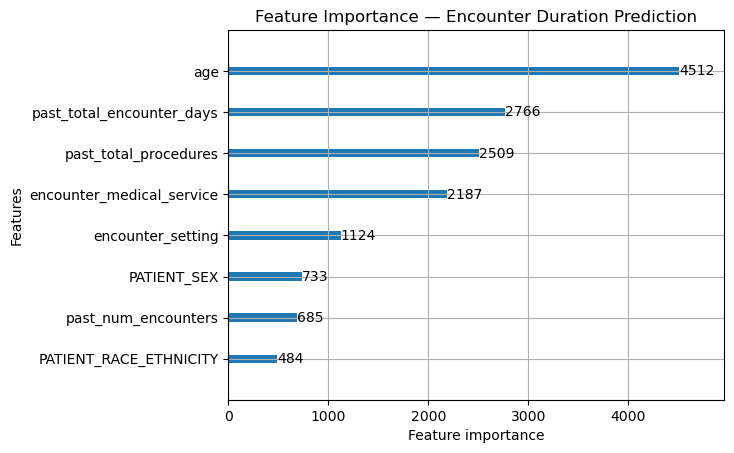

In [6]:
# ============================================
# 1. Import libraries
# ============================================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from lightgbm import LGBMRegressor
import lightgbm as lgb
import matplotlib.pyplot as plt

# ============================================
# 2. Load data
# ============================================
# df = pd.read_csv("/Users/KrisLiu/Downloads/patient_features_final_with_past.csv")

# ============================================
# 3. Select features available at encounter start
# ============================================
features = [
    'age', 'PATIENT_SEX', 'PATIENT_RACE_ETHNICITY',
    'encounter_setting', 'encounter_medical_service',
    'past_num_encounters', 'past_total_procedures',
    'past_total_icd_codes', 'past_total_encounter_days'
]

# Targets
target_encounter_count = 'past_num_encounters'         # historical pattern predictor
target_duration = 'encounter_duration_days'            # predict stay length

# ============================================
# 4. Encode categorical variables
# ============================================
df_encoded = df.copy()
for col in ['PATIENT_SEX', 'PATIENT_RACE_ETHNICITY', 'encounter_setting', 'encounter_medical_service']:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# ============================================
# 5. Split data
# ============================================
X = df_encoded[features]
y_days = df_encoded[target_duration]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_days, test_size=0.2, random_state=42
)

# ============================================
# 6. Train LightGBM model
# ============================================
model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)
model.fit(X_train, y_train)

# ============================================
# 7. Evaluate performance
# ============================================
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (days): {mae:.3f}")
print(f"R² score: {r2:.3f}")

# ============================================
# 8. Feature importance
# ============================================
plt.figure(figsize=(8,5))
lgb.plot_importance(model, max_num_features=10)
plt.title("Feature Importance — Encounter Duration Prediction")
plt.show()


/tmp/ipykernel_96015/791018840.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col].astype(str))
/tmp/ipykernel_96015/791018840.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col].astype(str))
/tmp/ipykernel_96015/791018840.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/p

[LightGBM] [Info] Number of positive: 4751, number of negative: 7341
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001157 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 304
[LightGBM] [Info] Number of data points in the train set: 12092, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.392904 -> initscore=-0.435120
[LightGBM] [Info] Start training from score -0.435120
AUC: 0.8774658806657717
              precision    recall  f1-score   support

           0       0.82      0.83      0.82      1836
           1       0.73      0.72      0.72      1188

    accuracy                           0.79      3024
   macro avg       0.78      0.77      0.77      3024
weighted avg       0.78      0.79      0.79      3024



<Figure size 800x500 with 0 Axes>

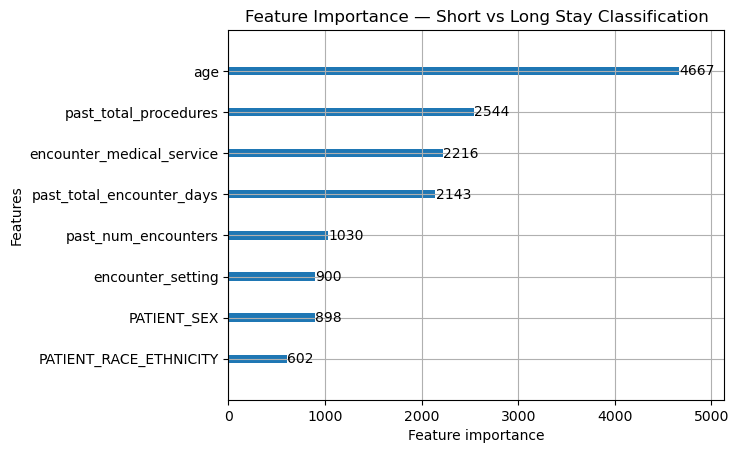

In [10]:
from sklearn.metrics import classification_report, roc_auc_score
from lightgbm import LGBMClassifier

# Create binary target (short vs long stay)
# ======================================================
df["long_stay_flag"] = (df["encounter_duration_days"] > 5).astype(int)

# ======================================================
# Select features (known at encounter start)
# ======================================================
features = [
    'age', 'PATIENT_SEX', 'PATIENT_RACE_ETHNICITY',
    'encounter_setting', 'encounter_medical_service',
    'past_num_encounters', 'past_total_procedures',
    'past_total_icd_codes', 'past_total_encounter_days'
]

X = df[features]
y = df["long_stay_flag"]

# ======================================================
# Encode categorical features
# ======================================================
df_encoded = df.copy()
for col in ['PATIENT_SEX', 'PATIENT_RACE_ETHNICITY', 'encounter_setting', 'encounter_medical_service']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# ======================================================
# Split train/test
# ======================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ======================================================
# Train LightGBM Classifier
# ======================================================
clf = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

clf.fit(X_train, y_train)

# ======================================================
# Evaluate model
# ======================================================
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

# ======================================================
# Feature importance plot
# ======================================================
plt.figure(figsize=(8,5))
lgb.plot_importance(clf, max_num_features=10)
plt.title("Feature Importance — Short vs Long Stay Classification")
plt.show()
